# Constant-Thickness STW under Uniform Tip Load

This notebook documents the Nastran linear buckling (SOL 105) analysis of the Simple Transonic Wing (STW) wingbox with uniform thickness under uniform tip load. Other analyses of the same structure have been performed using a linearly distributed load at the wingbox tip, defined in such a way to decrease the load from the rear spar to the front spar. This was done to induce the typical twist down of backward-swept wings. However, the twis-down behavior of backward-swept wings is naturally casued by their geometry, and there is no need to induce it through a linearly varying load at the tip.

In this notebook we use a uniformly distributed tip load and we observe the tip twist of the wingbox.

***

Import shared utilities and define case-specific constants.

In [1]:
# Import system and OS modules to manage the Python path and file system interactions
import sys
import os

# When Jupyter's CWD is the notebook's own directory (stw-nastran-vs-cuf/),
# the project's `resources` package is not on sys.path.  Detect this and add
# the parent directory (notebooks/) automatically.
_parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(_parent, "resources")) and _parent not in sys.path:
    sys.path.insert(0, _parent)

# Import third-party libraries and functions
import numpy as np
from pyNastran.op2.op2 import read_op2
import openmdao.api as om

# Import custom utilities
from resources import pynastran_utils
from resources import plot_utils
from resources.STW import nastran_vs_cuf_utils
from resources.STW import stw_utils
from resources.STW import wingGeometry

# ── Case-specific constants ───────────────────────────────────────────────────
ANALYSIS_DIR = nastran_vs_cuf_utils.ANALYSIS_DIRECTORY_PATH
FIRST_SUBCASE_ID = nastran_vs_cuf_utils.FIRST_SUBCASE_ID
SECOND_SUBCASE_ID = nastran_vs_cuf_utils.SECOND_SUBCASE_ID
METHOD_SET_ID = nastran_vs_cuf_utils.METHOD_SET_ID
INPUT_NAME_SUFFIX = "constant_thickness_uniform_tip_load"

# Applied load parameters
TOTAL_FORCE = 1.0  # reference unit load [N]
FORCE_RATIO = (
    1.0  # F(front spar) / F(rear spar) - we use a value of 1.0 to apply a uniform load
)
FORCE_SET_ID = 1  # SID of the FORCE cards

# SOL 105 amplification factor for mode-shape visualisation
AMPLIFICATION_FACTOR = 2

Configure default plotting settings.

In [2]:
import matplotlib.pyplot as plt

nastran_vs_cuf_utils.configure_plotting()

COLORS = nastran_vs_cuf_utils.COLORS
MARKERS = nastran_vs_cuf_utils.MARKERS
GLASS_CEILING_COLOR = nastran_vs_cuf_utils.GLASS_CEILING_COLOR
TEXTWIDTH_INCHES = nastran_vs_cuf_utils.TEXTWIDTH_INCHES
FIG_HEIGHT_INCHES = nastran_vs_cuf_utils.FIG_HEIGHT_INCHES

Create STW structural model with the same mesh as the [SciTech 2025 paper](https://doi.org/10.2514/6.2025-2811).

In [3]:
target_length = 53e-3  # target element edge length [m]
stw_bdf, stw_layout = wingGeometry.create_base_bdf(target_length)
print(stw_bdf.get_bdf_stats())

pyGeo Initialization Type is: iges
Found 6 surfaces in Iges File.
Projecting Super Nodes...
Projecting All Nodes...
Setting up Ribs...
Setting up Spars...
Setting up Skins and Stringers...
Setting up Spar Bars
Setting up Rib Bars
Computing Topology and Numbering...
Unique Nodes: 45483
Total Nodes: 65046
Writing .bdf File...
---BDF Statistics---
SOL 103

bdf.spcs[1]: 354
  SPC:     354

bdf.params: 0
  PARAM    : 1

bdf.nodes: 45483
  GRID     : 45483

bdf.elements: 46432
  CQUAD4   : 46432

bdf.properties: 0
  PSHELL   : 1110

bdf.materials: 0
  MAT1     : 1




subcase=0 already exists...skipping


## Definition of Uniform Tip Load

We apply a uniform upward force at the wingbox tip. The total reference force is 1 N, split equally between the upper and lower skin nodes.

In [4]:
# Create deep copy of the base BDF for load application
uniform_tip_load_bdf = stw_bdf.__deepcopy__({})

# Apply uniform tip load
stw_utils.apply_distributed_tip_load(
    layout=stw_layout,
    bdf=uniform_tip_load_bdf,
    ratio=FORCE_RATIO,
    total_force=TOTAL_FORCE,
    set_id=FORCE_SET_ID,
)

# Create the static-load subcase
pynastran_utils.create_static_load_subcase(
    bdf=uniform_tip_load_bdf,
    load_set_id=FORCE_SET_ID,
    subcase_id=FIRST_SUBCASE_ID,
)

## Linear Buckling Analysis (SOL 105)

### Set Up

In [5]:
# Create deep copy of the load BDF for SOL 105
sol_105_bdf = uniform_tip_load_bdf.__deepcopy__({})

# Set up linear buckling solution with eigenvalue method set
pynastran_utils.set_up_sol_105(
    bdf=sol_105_bdf,
    static_load_set_id=FORCE_SET_ID,
    method_set_id=METHOD_SET_ID,
)

# Request element stress output for post-processing
sol_105_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

subcase=1 already exists...skipping


### Run

In [6]:
# Define OpenMDAO linear buckling problem
linear_problem = om.Problem(name="sol_105_distributed_tip_load")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=INPUT_NAME_SUFFIX,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_105_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
linear_problem.setup()
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_105_constant_thickness_uniform_tip_load.bdf completed
Wall time: 42.0 s


### Results

Read the op2 file, print the linear buckling load, and plot the critical buckling mode shape.

Linear buckling load: 133261.86 N


/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


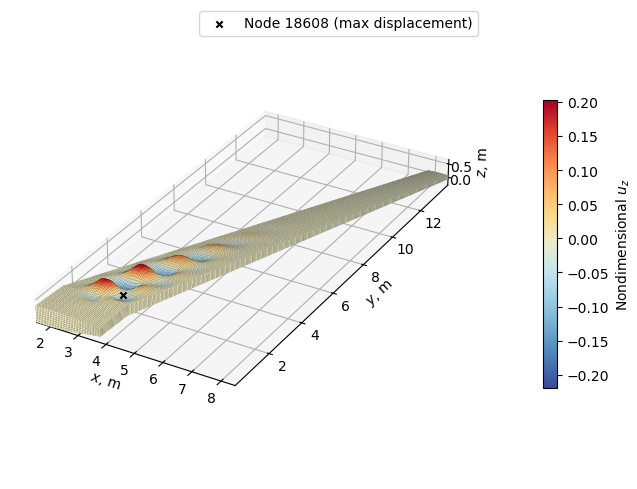


Max-displacement node ID : 18608
Node coordinates [x, y, z] (m): [3.02882401 2.48676316 0.27278431]


In [7]:
%matplotlib widget

# Read op2 file
sol_105_op2_path = os.path.join(ANALYSIS_DIR, f"sol_105_{INPUT_NAME_SUFFIX}.op2")
sol_105_op2 = read_op2(sol_105_op2_path, load_geometry=True, debug=None)

# Extract and print linear buckling load
# Note that the eigenvalues of SOL 105 are buckling load factors, that is to say
# P_buckling/P_applied. Since we applied a reference load of 1 N, the buckling load
# factor is numerically equal to the buckling load in Newtons.
linear_buckling_load = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Linear buckling load: {linear_buckling_load:.2f} N")

# Plot critical buckling mode shape
_, ax, _ = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=AMPLIFICATION_FACTOR,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)

# Mark and record the node with maximum out-of-plane displacement
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_105_op2, displacement_amplification_factor=AMPLIFICATION_FACTOR
)

# Add plot legend, adjust 3D plot settings, and display
ax.legend()
nastran_vs_cuf_utils.adjust_3d_plot(ax)
plt.show()

# Print the ID and coordinates of the node with maximum out-of-plane displacement
print(f"\nMax-displacement node ID : {max_disp_node_id}")
print(f"Node coordinates [x, y, z] (m): {sol_105_op2.nodes[max_disp_node_id].xyz}")

Measure tip twist angle.

In [8]:
# Measure tip twist angle
tip_nodes_ids, tip_nodes_coords = stw_utils.find_tip_nodes(stw_layout, sol_105_op2)
tip_nodes_disp = pynastran_utils.read_displacement_from_op2(
    op2=sol_105_op2, node_ids=tip_nodes_ids
)
tip_twist = stw_utils.calculate_tip_twist(
    tip_nodes_coords[1],
    tip_nodes_coords[0],
    tip_nodes_disp[tip_nodes_ids[1]][FIRST_SUBCASE_ID],
    tip_nodes_disp[tip_nodes_ids[0]][FIRST_SUBCASE_ID],
)

# Print the calculated tip twist angle in degrees
print(
    f"\nTip twist angle under {TOTAL_FORCE:.0f} N uniform load: {np.degrees(tip_twist[0]):.5f} degrees"
)
print(
    f"Tip twist angle under linear buckling load (assumption of linear behaviour): {np.degrees(tip_twist[0] * linear_buckling_load):.1f} degrees"
)


Tip twist angle under 1 N uniform load: -0.00004 degrees
Tip twist angle under linear buckling load (assumption of linear behaviour): -5.2 degrees
